# Valutazione della Robustezza Adversarial di YOLO su Dataset Completo

Questo notebook estende la valutazione degli attacchi adversarial (**FGSM** e **PGD**) a tutti i file video presenti nelle cartelle `DATA/video` e `DATA/render`.

Il codice:
1. Scansiona ricorsivamente le cartelle dividendole in due gruppi principali.
2. Calcola la baseline dinamica (senza attacco) per ciascun singolo video.
3. Esegue lo sweep di `epsilon` per gli attacchi FGSM e PGD.
4. Aggrega i risultati calcolando la **media statistica** delle metriche per ogni gruppo, permettendo un confronto diretto tra video reali e renderizzati.

## 1. Import dei moduli e configurazione dei parametri

In [ ]:
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Import delle funzioni custom dal tuo file adversarial.py
from adversarial import fgsm_attack, pgd_attack, _detach_inference_buffers

# Inizializzazione del modello YOLO
from ultralytics import YOLO
#model = YOLO("yolov8n.pt")  # Sostituisci con il tuo eventuale modello custom (.pt)
model = YOLO("yolov11n.pt")

# Sblocca i tensori di cache interni di YOLO per permettere il calcolo del gradiente (autograd)
_detach_inference_buffers(model.model)

# Configurazione dei percorsi
BASE_DIR = Path(".").resolve().parent
VIDEO_DIR = BASE_DIR / "DATA" / "video"
RENDER_DIR = BASE_DIR / "DATA" / "render"

# Parametri globali di valutazione
FRAME_INDICES = [10, 30, 50, 70, 90]
EPSILON_VALUES = [0, 0.01, 0.02, 0.03, 0.05, 0.1]
CONF_THRESHOLD = 0.25

## 2. Funzioni di Utilità per Frame e Detections

In [13]:
def load_eval_frames(video_path, frame_indices, img_size=640, device="cpu"):
    """
    Carica frame specifici da un video, li ridimensiona a 640x640 e li converte 
    in tensori PyTorch pronti per l'attacco adversarial [1, 3, 640, 640] con gradienti attivi.
    """
    cap = cv2.VideoCapture(str(video_path))
    frames = []
    if not cap.isOpened():
        raise IOError(f"Impossibile aprire il file video: {video_path}")
        
    for idx in sorted(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            break
            
        # Forza il ridimensionamento a 640x640 (indispensabile per YOLOv8 in backward)
        frame_resized = cv2.resize(frame, (img_size, img_size))
        
        # Conversione BGR -> RGB e normalizzazione [0, 1]
        frame_rgb = cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB)
        
        # Creazione del tensore [C, H, W]
        frame_tensor = torch.from_numpy(frame_rgb).permute(2, 0, 1).float() / 255.0
        
        # Aggiunta della dimensione del batch -> [1, C, H, W] e spostamento sul device
        frame_tensor = frame_tensor.unsqueeze(0).to(device)
        
        # CRITICO: Attiva esplicitamente il tracciamento dei gradienti richiesto da FGSM/PGD
        frame_tensor.requires_grad_(True)
        
        frames.append(frame_tensor)
        
    cap.release()
    return frames

def tensor_to_image(tensor):
    """Converte un tensore [1, C, H, W] o [C, H, W] in un'immagine numpy RGB [H, W, C] per YOLO"""
    if tensor.dim() == 4:
        tensor = tensor.squeeze(0)
    # Usiamo .detach() per scollegare il tensore dal grafo prima di convertirlo in NumPy
    img = tensor.detach().cpu().permute(1, 2, 0).numpy() * 255.0
    return img.astype(np.uint8)

def get_detections(model, img, conf_threshold):
    """
    Esegue l'inferenza classica. Passiamo l'immagine convertita in NumPy 
    per assicurarci che YOLO usi la sua pipeline di predizione pulita standard.
    """
    results = model(img, conf=conf_threshold, verbose=False)
    boxes = results[0].boxes
    n_det = len(boxes)
    mean_conf = float(boxes.conf.mean().item()) if n_det > 0 else 0.0
    return n_det, mean_conf

## 3. Funzione di Valutazione del Singolo Epsilon

In [14]:
def evaluate_epsilon(model, eval_frames, baseline_counts, epsilon, conf_threshold, method="fgsm"):
    """
    Valuta l'impatto di un determinato valore di epsilon su un set di frame pre-caricati.
    Gestisce correttamente l'output a tupla delle funzioni fgsm_attack e pgd_attack.
    """
    det_counts = []
    confidences = []
    
    for i, tensor in enumerate(eval_frames):
        if epsilon == 0:
            perturbed_tensor = tensor
        else:
            # Clona il tensore mantenendo intatta la richiesta del gradiente
            input_tensor = tensor.clone().detach().requires_grad_(True)
            
            if method.lower() == "fgsm":
                # Spacchettiamo la tupla: prendiamo solo il tensore perturbato [0] e ignoriamo il resto
                perturbed_tensor, _ = fgsm_attack(model, input_tensor, epsilon)
            elif method.lower() == "pgd":
                # Spacchettiamo la tupla anche per il PGD
                perturbed_tensor, _ = pgd_attack(model, input_tensor, epsilon)
            else:
                perturbed_tensor = input_tensor
                
        # Ora perturbed_tensor è sicuramente un oggetto torch.Tensor e tensor_to_image funzionerà
        img = tensor_to_image(perturbed_tensor)
        n_det, m_conf = get_detections(model, img, conf_threshold)
        det_counts.append(n_det)
        confidences.append(m_conf)
        
    avg_detections = np.mean(det_counts)
    avg_confidence = np.mean(confidences)
    
    total_baseline_detections = np.sum(baseline_counts)
    if total_baseline_detections > 0:
        dropped_detections = total_baseline_detections - np.sum(det_counts)
        asr = max(0.0, float(dropped_detections / total_baseline_detections))
    else:
        asr = 0.0
        
    return {
        "n_detections": avg_detections,
        "mean_confidence": avg_confidence,
        "asr": asr
    }

## 4. Pipeline Massiva per tutti i Video (Video vs Render)

In [15]:
folders_to_process = {
    "Video": VIDEO_DIR,
    "Render": RENDER_DIR
}

valid_extensions = {".mp4", ".avi", ".mov", ".mkv"}
all_video_records = []

for group_name, folder_path in folders_to_process.items():
    print(f"\n" + "="*60)
    print(f"Inizio elaborazione gruppo: {group_name} ({folder_path})")
    print("="*60)
    
    if not folder_path.exists():
        print(f"[WARNING] La cartella {folder_path} non esiste. Salto il gruppo.")
        continue
        
    video_files = [p for p in folder_path.iterdir() if p.is_file() and p.suffix.lower() in valid_extensions]
    
    if not video_files:
        print(f"Nessun video valido trovato in {folder_path}")
        continue
        
    for video_path in video_files:
        print(f"\n--> Elaborazione video: {video_path.name}")
        
        try:
            current_eval_frames = load_eval_frames(video_path, FRAME_INDICES)
            
            current_baseline_counts = []
            for tensor in current_eval_frames:
                img = tensor_to_image(tensor)
                n, _ = get_detections(model, img, CONF_THRESHOLD)
                current_baseline_counts.append(n)
                
            for epsilon in EPSILON_VALUES:
                # FGSM
                res_fgsm = evaluate_epsilon(model, current_eval_frames, current_baseline_counts, epsilon, CONF_THRESHOLD, method="fgsm")
                all_video_records.append({
                    "Gruppo": group_name,
                    "Video": video_path.name,
                    "epsilon": epsilon,
                    "method": "FGSM",
                    **res_fgsm
                })
                
                # PGD
                if epsilon == 0:
                    res_pgd = res_fgsm
                else:
                    res_pgd = evaluate_epsilon(model, current_eval_frames, current_baseline_counts, epsilon, CONF_THRESHOLD, method="pgd")
                
                all_video_records.append({
                    "Gruppo": group_name,
                    "Video": video_path.name,
                    "epsilon": epsilon,
                    "method": "PGD",
                    **res_pgd
                })
                
        except Exception as e:
            print(f"[ERROR] Errore nell'elaborazione del video {video_path.name}: {e}")

print("\n" + "="*60)
print("ELABORAZIONE COMPLETA DI TUTTI I VIDEO")
print("="*60)


Inizio elaborazione gruppo: Video (/Users/salvatoremariocarota/Documents/Github/ComputerVisionLAB/DATA/video)

--> Elaborazione video: crime_knife.mp4

--> Elaborazione video: crime_scene.mp4

Inizio elaborazione gruppo: Render (/Users/salvatoremariocarota/Documents/Github/ComputerVisionLAB/DATA/render)

--> Elaborazione video: crime.mp4

--> Elaborazione video: splacto_living_room.mp4

ELABORAZIONE COMPLETA DI TUTTI I VIDEO


## 5. Analisi e Calcolo delle Medie per Gruppo

In [16]:
df_all_results = pd.DataFrame(all_video_records)
df_all_results.to_csv("risultati_granulari_video.csv", index=False)

df_group_means = df_all_results.groupby(["Gruppo", "epsilon", "method"])[["n_detections", "mean_confidence", "asr"]].mean().reset_index()
df_group_means

,Gruppo,epsilon,method,n_detections,mean_confidence,asr
0,Render,0.00,FGSM,4.400,0.609468,0.000000
1,Render,0.00,PGD,4.400,0.609468,0.000000
2,Render,0.01,FGSM,2.600,0.399838,0.491315
3,Render,0.01,PGD,0.000,0.000000,1.000000
4,Render,0.02,FGSM,2.300,0.330108,0.584367
5,Render,0.02,PGD,0.000,0.000000,1.000000
6,Render,0.03,FGSM,2.200,0.285135,0.600496
7,Render,0.03,PGD,0.000,0.000000,1.000000
8,Render,0.05,FGSM,1.200,0.256159,0.806452
9,Render,0.05,PGD,0.000,0.000000,1.000000


## 6. Generazione Grafici Comparativi (Video vs Render)

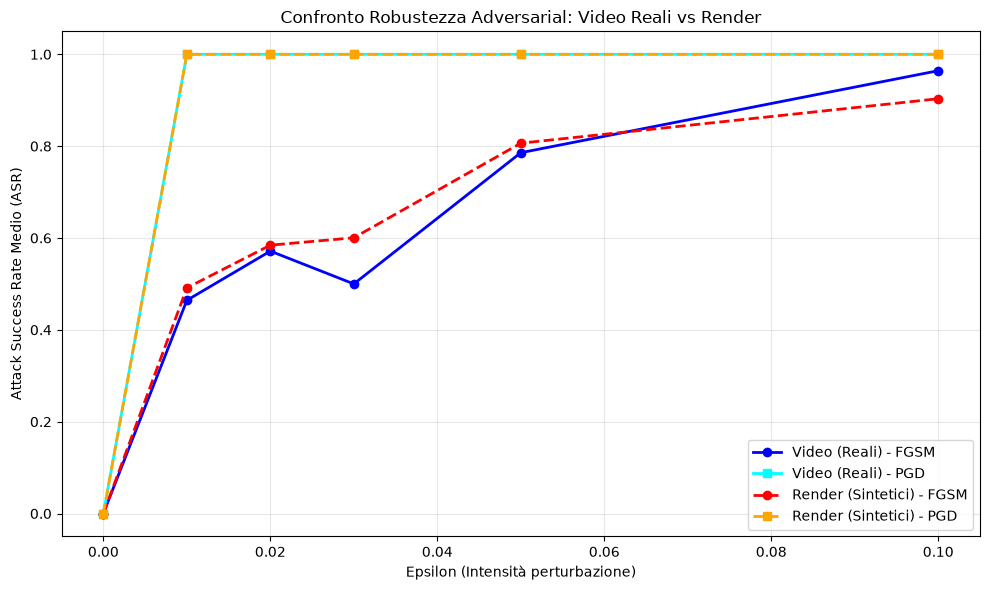

In [17]:
df_video = df_group_means[df_group_means["Gruppo"] == "Video"]
df_render = df_group_means[df_group_means["Gruppo"] == "Render"]

fig, ax = plt.subplots(figsize=(10, 6))

# Plot Video Reali
ax.plot(df_video[df_video["method"]=="FGSM"]["epsilon"], df_video[df_video["method"]=="FGSM"]["asr"], 
        'o-', label='Video (Reali) - FGSM', color='blue', linewidth=2)
ax.plot(df_video[df_video["method"]=="PGD"]["epsilon"], df_video[df_video["method"]=="PGD"]["asr"], 
        's-', label='Video (Reali) - PGD', color='cyan', linewidth=2)

# Plot Render Sintetici
ax.plot(df_render[df_render["method"]=="FGSM"]["epsilon"], df_render[df_render["method"]=="FGSM"]["asr"], 
        'o--', label='Render (Sintetici) - FGSM', color='red', linewidth=2)
ax.plot(df_render[df_render["method"]=="PGD"]["epsilon"], df_render[df_render["method"]=="PGD"]["asr"], 
        's--', label='Render (Sintetici) - PGD', color='orange', linewidth=2)

ax.set_xlabel("Epsilon (Intensità perturbazione)")
ax.set_ylabel("Attack Success Rate Medio (ASR)")
ax.set_title("Confronto Robustezza Adversarial: Video Reali vs Render")
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("confronto_robustezza_groups.png", dpi=300)
plt.show()